<a href="https://colab.research.google.com/github/yasaswitaraja/SentinelNet/blob/main/KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()



Saving KDDTrain+.txt to KDDTrain+ (1).txt


In [1]:
# This is a list of all 41 feature names, plus the final 'class' label.
# Source: http://kdd.ics.uci.edu/databases/kddcup99/kddcup.names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'class', 'difficulty'
]

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("KDDTrain+.txt", names=column_names)
test_df = pd.read_csv("KDDTest+.txt", names=column_names)

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)
print("Training data columns:", train.columns)
print("Testing data columns:", test.columns)

print("--- Training Data ---")
print(f"Shape: {train_df.shape}")
print(train_df.head())

print("\n--- Testing Data ---")
print(f"Shape: {test_df.shape}")
print(test_df.head())



Training data shape: (125973, 43)
Testing data shape: (22544, 43)
Training data columns: Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty'],
      dtype='object')
Testing data columns: Index(['duration', 'prot

In [8]:
print("\n--- Training Data Info ---")
train_df.info()

print("\n--- Missing Values ---")
print(train_df.isnull().sum().sum())


--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              1

/tmp/ipython-input-1446411240.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=train_df, palette='pastel')


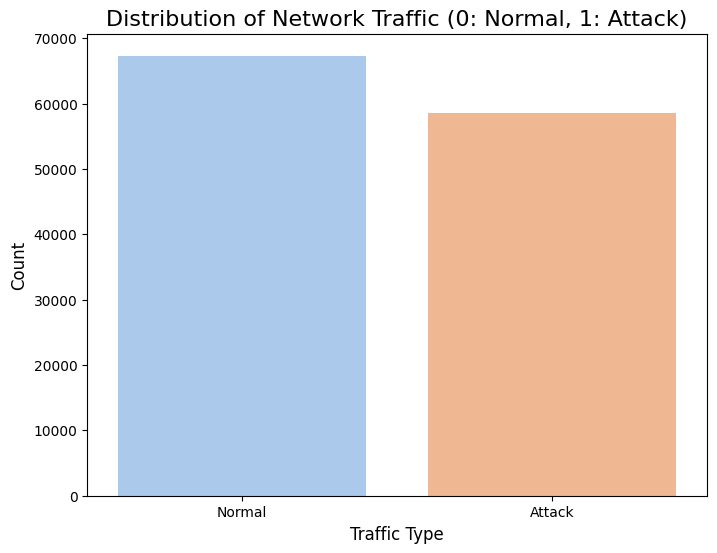

attack_binary
0    0.534583
1    0.465417
Name: proportion, dtype: float64


In [9]:
# Create a binary classification target
train_df['attack_binary'] = train_df['class'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack_binary'] = test_df['class'].apply(lambda x: 0 if x == 'normal' else 1)

# Distribution of the binary class
plt.figure(figsize=(8, 6))
sns.countplot(x='attack_binary', data=train_df, palette='pastel')
plt.title('Distribution of Network Traffic (0: Normal, 1: Attack)', fontsize=16)
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Attack'])
plt.show()

print(train_df['attack_binary'].value_counts(normalize=True))

/tmp/ipython-input-3039002362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=attack_df, order=attack_df['class'].value_counts().index, palette='viridis')


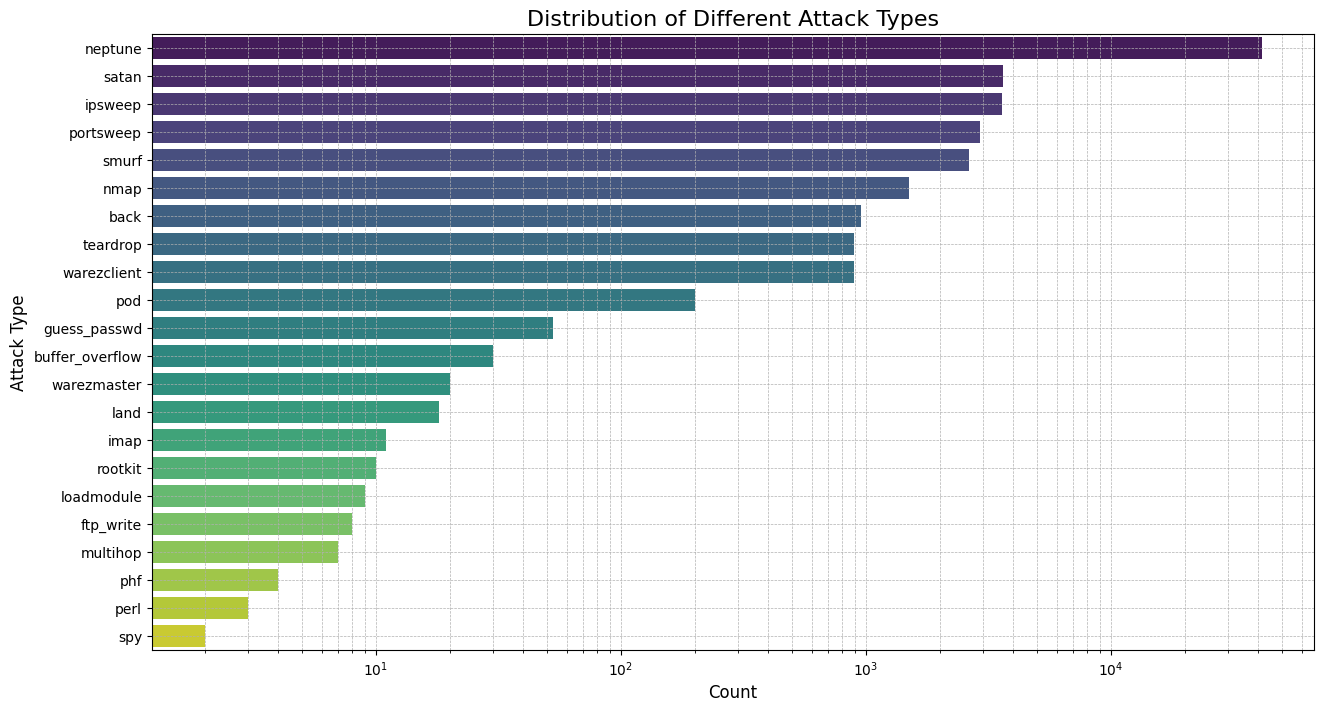

In [10]:
# Filter for attack traffic only
attack_df = train_df[train_df['attack_binary'] == 1]

plt.figure(figsize=(15, 8))
sns.countplot(y='class', data=attack_df, order=attack_df['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Different Attack Types', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.xscale('log') # Use a log scale for better visibility of less frequent attacks
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

/tmp/ipython-input-1351026870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='protocol_type', data=train_df, palette='magma')
/tmp/ipython-input-1351026870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='service', data=train_df, order=train_df['service'].value_counts().iloc[:10].index, palette='plasma')
/tmp/ipython-input-1351026870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[2], x='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='cividis')


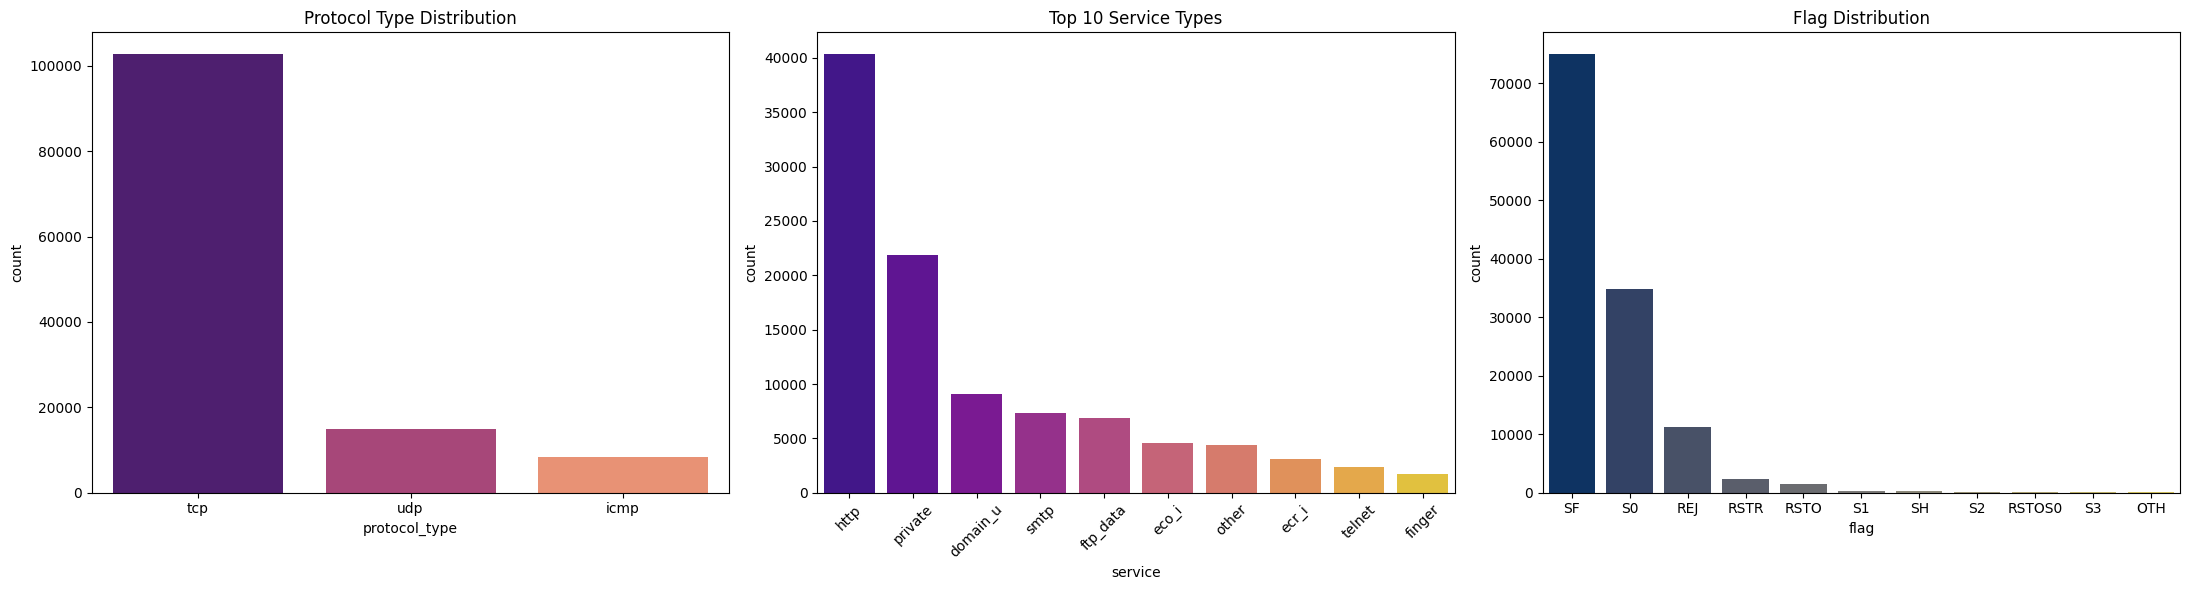

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(ax=axes[0], x='protocol_type', data=train_df, palette='magma')
axes[0].set_title('Protocol Type Distribution')

sns.countplot(ax=axes[1], x='service', data=train_df, order=train_df['service'].value_counts().iloc[:10].index, palette='plasma')
axes[1].set_title('Top 10 Service Types')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[2], x='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='cividis')
axes[2].set_title('Flag Distribution')

plt.tight_layout()
plt.show()

In [12]:
# Separate features (X) and target (y)
X_train_raw = train_df.drop(['class', 'attack_binary'], axis=1)
y_train = train_df['attack_binary']

X_test_raw = test_df.drop(['class', 'attack_binary'], axis=1)
y_test = test_df['attack_binary']

# Identify categorical and numerical columns
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = X_train_raw.columns.drop(categorical_cols)

# One-Hot Encode categorical features
X_train_encoded = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=True)

# Align columns - crucial for ensuring test set has same features as train set
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols] # Ensure order is the same

print(f"Shape of training data after encoding: {X_train_encoded.shape}")
print(f"Shape of testing data after encoding: {X_test_encoded.shape}")

Shape of training data after encoding: (125973, 120)
Shape of testing data after encoding: (22544, 120)


In [13]:
from sklearn.preprocessing import StandardScaler

# Identify the new numerical columns (original ones)
numerical_cols_to_scale = numerical_cols

scaler = StandardScaler()

# Fit on training data and transform both train and test data
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(X_train_encoded[numerical_cols_to_scale])
X_test_scaled[numerical_cols_to_scale] = scaler.transform(X_test_encoded[numerical_cols_to_scale])

print("\n--- Scaled Training Data Head ---")
print(X_train_scaled.head())


--- Scaled Training Data Head ---
   duration  src_bytes  dst_bytes      land  wrong_fragment    urgent  \
0 -0.110249  -0.007679  -0.004919 -0.014089       -0.089486 -0.007736   
1 -0.110249  -0.007737  -0.004919 -0.014089       -0.089486 -0.007736   
2 -0.110249  -0.007762  -0.004919 -0.014089       -0.089486 -0.007736   
3 -0.110249  -0.007723  -0.002891 -0.014089       -0.089486 -0.007736   
4 -0.110249  -0.007728  -0.004814 -0.014089       -0.089486 -0.007736   

        hot  num_failed_logins  logged_in  num_compromised  ...  flag_REJ  \
0 -0.095076          -0.027023  -0.809262        -0.011664  ...     False   
1 -0.095076          -0.027023  -0.809262        -0.011664  ...     False   
2 -0.095076          -0.027023  -0.809262        -0.011664  ...     False   
3 -0.095076          -0.027023   1.235694        -0.011664  ...     False   
4 -0.095076          -0.027023   1.235694        -0.011664  ...     False   

   flag_RSTO  flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  flag_S2

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


models={
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(),
}

# Train the models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    print(name + " trained.")

# Evaluate the models
for name, model in models.items():
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Training Logistic Regression...
Logistic Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.
Training Gradient Boosting...
Gradient Boosting trained.
Evaluating Logistic Regression...
Logistic Regression Accuracy: 81.09%

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Normal       0.72      0.92      0.81      9711
      Attack       0.92      0.73      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.82      0.82      0.81     22544
weighted avg       0.83      0.81      0.81     22544

Evaluating Decision Tree...
Decision Tree Accuracy: 84.65%

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      0.97      0.84      9711
      Attack       0.97      0.75      0.85     12833

    accuracy                           0.85     22544
   macro avg       0.86    

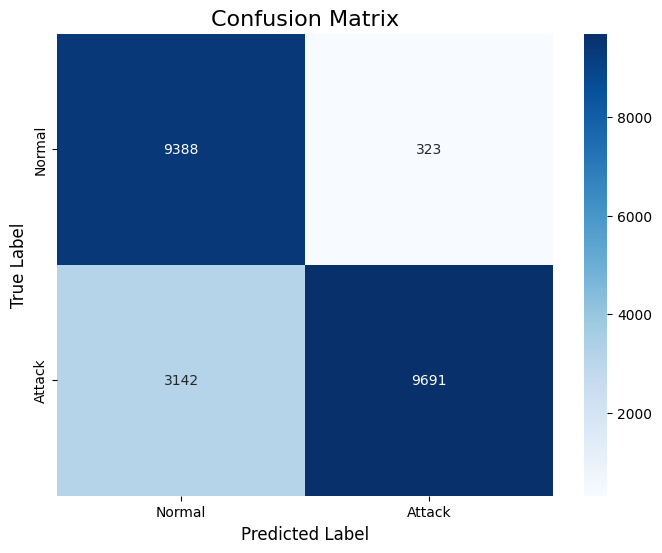

In [23]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()